# USAGE: PUT RAW DATA IN ../data/wifi_samples.csv, PLUG-AND-PLAY

## Preliminary processing and cleaning of raw samples

In [31]:
# import json
import math
from io import BytesIO
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PolyCollection

CSV_PATH = Path("../data/wifi_samples.csv")
PHONE_LOCATION_LOG_PATH = Path("../data/phone_location_log.csv")
WDUTIL_RSSI_PLACEHOLDER_FILL_DBM = None
ASOF_COORDINATE_LOOKBACK = pd.Timedelta(seconds=30)


NUMERIC_COLUMNS = [
    "sample_index",
    "floor",
    "wdutil_rssi_dbm",
    "wdutil_noise_dbm",
]

## tmp corruption correction

In [32]:
# tmp_df = pd.read_csv(CSV_PATH)
# cols = tmp_df.columns.to_list()
# ordered_c = cols[:32]
# clean_ordered_c = [s.strip() for s in ordered_c]
# replace_c = cols[32:]
# clean_tmp_df = tmp_df[ordered_c]
# clean_tmp_df.columns = clean_ordered_c
# for col in clean_ordered_c[1:]:
#     c_rep = [
#         s for s in replace_c
#         if s.replace(".1", "").strip() == col
#     ]
#     assert len(c_rep) == 1
#     c_rep = c_rep[0]

#     clean_tmp_df.loc[
#         clean_tmp_df[col].str.strip() == "null",
#         col
#     ] = tmp_df.loc[
#         clean_tmp_df[col].str.strip() == "null",
#         c_rep
#     ]

# for col in clean_tmp_df.columns:
#     clean_tmp_df[col] = clean_tmp_df[col].str.strip()
# clean_tmp_df

In [33]:
# clean_tmp_df.to_csv("../data/wifi_samples.csv", index=False)

## WiFi Raw df

In [34]:
def resolve_rssi_placeholder_fill_value(wifi_df):
    '''
    NOTE USED: fill with np.nan for now
    '''

    if WDUTIL_RSSI_PLACEHOLDER_FILL_DBM is not None:
        return float(WDUTIL_RSSI_PLACEHOLDER_FILL_DBM)
    observed_rssi = wifi_df.loc[
        wifi_df["wdutil_rssi_dbm"].notna() & wifi_df["wdutil_rssi_dbm"].ne(0),
        "wdutil_rssi_dbm",
    ]
    if observed_rssi.empty:
        raise ValueError(
            "Could not infer an RSSI fill value because there are no nonzero wdutil_rssi_dbm values.")

    observed_noise = wifi_df.loc[
        wifi_df["wdutil_noise_dbm"].notna(
        ) & wifi_df["wdutil_noise_dbm"].ne(0),
        "wdutil_noise_dbm",
    ]
    return float(observed_rssi.min()), float(observed_noise.min())


In [35]:
DATAFRAME_COLUMNS = [
    "measurement_set_id",
    "sample_index",
    "collector_id",
    "environment",
    "floor",
    "measurement_set_timestamp_utc",
    "sample_timestamp_utc",
    "wdutil_rssi_dbm",
    "wdutil_rssi_effective_dbm",
    "wdutil_noise_dbm",
    "wdutil_noise_effective_dbm",
    "wdutil_tx_rate",
    # "wdutil_zero_placeholder",
    "unredactor_bssid"
]

def build_wifi_dataframe(csv_path=CSV_PATH):
    wifi_df = pd.read_csv(csv_path, na_values=[
                          "null", "none", "nan"], keep_default_na=True)

    for column in wifi_df.columns:
        if pd.api.types.is_object_dtype(wifi_df[column]) or pd.api.types.is_string_dtype(wifi_df[column]):
            wifi_df[column] = wifi_df[column].map(
                lambda value: value.strip() if isinstance(value, str) else value
            )
    wifi_df = wifi_df.replace(r"^\\s*$", pd.NA, regex=True)

    for column in NUMERIC_COLUMNS:
        if column in wifi_df.columns:
            wifi_df[column] = pd.to_numeric(wifi_df[column], errors="coerce")

    wifi_df["wdutil_tx_rate"] = pd.to_numeric(
        wifi_df["wdutil_tx_rate"].astype(
            "string").str.extract(r"([0-9.]+)", expand=False),
        errors="coerce",
    )

    # wifi_df["wdutil_zero_placeholder"] = (
    #     wifi_df["wdutil_rssi_dbm"].eq(0) | wifi_df["wdutil_noise_dbm"].eq(0)
    # )

    wifi_df["wdutil_rssi_effective_dbm"] = wifi_df["wdutil_rssi_dbm"]
    wifi_df["wdutil_noise_effective_dbm"] = wifi_df["wdutil_noise_dbm"]
    wifi_df.loc[wifi_df["wdutil_rssi_dbm"].eq(0),
                "wdutil_rssi_effective_dbm"] = np.nan
    wifi_df.loc[wifi_df["wdutil_noise_dbm"].eq(0),
                "wdutil_noise_effective_dbm"] = np.nan

    wifi_df["measurement_set_timestamp_utc"] = pd.to_datetime(
        wifi_df["measurement_set_timestamp_utc"],
        format="mixed",
        utc=True,
    )
    wifi_df["sample_timestamp_utc"] = pd.to_datetime(
        wifi_df["sample_timestamp_utc"],
        format="mixed",
        utc=True,
    )

    return wifi_df.reindex(columns=DATAFRAME_COLUMNS)



In [36]:
wifi_df = build_wifi_dataframe()

In [37]:
wifi_df.head()

,measurement_set_id,sample_index,collector_id,environment,floor,measurement_set_timestamp_utc,sample_timestamp_utc,wdutil_rssi_dbm,wdutil_rssi_effective_dbm,wdutil_noise_dbm,wdutil_noise_effective_dbm,wdutil_tx_rate,unredactor_bssid
0,07d6fa75def0,0,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:02.508330+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12
1,07d6fa75def0,1,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:03.719977+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12
2,07d6fa75def0,2,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:04.951550+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12
3,825d2cb1e35a,0,kevinluo,indoor,1,2026-04-28 00:11:07.403333+00:00,2026-04-28 00:11:07.470753+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12
4,825d2cb1e35a,1,kevinluo,indoor,1,2026-04-28 00:11:07.403333+00:00,2026-04-28 00:11:08.676819+00:00,-44,-44.0,-97,-97.0,573.0,a8:3a:79:c7:75:12


## Phone location df

In [38]:
ASOF_COORDINATE_COLUMNS = [
    "phone_gps_asof_timestamp",
    "phone_gps_asof_sample_index",
    "phone_gps_asof_latitude",
    "phone_gps_asof_longitude",
    "phone_gps_asof_altitude_m",
]

def build_phone_gps_asof_dataframe(wifi_df, phone_location_log_path=PHONE_LOCATION_LOG_PATH):
    phone_gps_asof_df = pd.DataFrame(
        index=wifi_df.index, columns=ASOF_COORDINATE_COLUMNS)
    phone_location_log_path = Path(phone_location_log_path)
    if not phone_location_log_path.exists():
        return phone_gps_asof_df

    phone_log_df = pd.read_csv(
        phone_location_log_path,
        header=None,
        names=ASOF_COORDINATE_COLUMNS,
        na_values=["null", "none", "nan"],
        keep_default_na=True,
    )

    for column in phone_log_df.columns:
        if pd.api.types.is_object_dtype(phone_log_df[column]) or pd.api.types.is_string_dtype(phone_log_df[column]):
            phone_log_df[column] = phone_log_df[column].map(
                lambda value: value.strip() if isinstance(value, str) else value
            )
    phone_log_df = phone_log_df.replace(r"^\\s*$", pd.NA, regex=True)

    for column in ASOF_COORDINATE_COLUMNS[1:]:
        phone_log_df[column] = pd.to_numeric(
            phone_log_df[column], errors="coerce")
        
    phone_log_df["phone_gps_asof_timestamp"] = pd.to_datetime(
        phone_log_df["phone_gps_asof_timestamp"],
        format="mixed",
        utc=True,
    )

    phone_log_df["phone_gps_asof_lookup_timestamp"] = phone_log_df["phone_gps_asof_timestamp"]


    phone_log_df = phone_log_df.dropna(subset=["phone_gps_asof_timestamp"]).sort_values(
        "phone_gps_asof_timestamp",
        kind="stable",
    )

    wifi_lookup_df = pd.DataFrame(index=wifi_df.index)
    wifi_lookup_df["__wifi_index"] = wifi_df.index
    wifi_lookup_df["phone_gps_asof_lookup_timestamp"] = wifi_df["sample_timestamp_utc"].combine_first(
        wifi_df["measurement_set_timestamp_utc"])
    valid_wifi_mask = wifi_lookup_df["phone_gps_asof_lookup_timestamp"].notna()

    if phone_log_df.empty or not valid_wifi_mask.any():
        return phone_gps_asof_df

    matched_asof_df = pd.merge_asof(
        wifi_lookup_df.loc[valid_wifi_mask].sort_values(
            "phone_gps_asof_lookup_timestamp",
            kind="stable",
        ),
        phone_log_df,
        on="phone_gps_asof_lookup_timestamp",
        direction="nearest",
        tolerance=ASOF_COORDINATE_LOOKBACK,
    ).set_index("__wifi_index")

    phone_gps_asof_df.loc[matched_asof_df.index, ASOF_COORDINATE_COLUMNS] = matched_asof_df[
        ASOF_COORDINATE_COLUMNS
    ]
    return phone_gps_asof_df

In [39]:
phone_location_df = pd.read_csv("../data/phone_location_log.csv",
                                header=None,
                                names=ASOF_COORDINATE_COLUMNS,
                                na_values=["null", "none", "nan"],
                                keep_default_na=True,).assign(
                                    latitude=lambda df: df["phone_gps_asof_latitude"].astype("float"),
                                    longitude=lambda df: df["phone_gps_asof_longitude"].astype("float"),
                                    timestamp=lambda df: pd.to_datetime(df["phone_gps_asof_timestamp"]),
                                )[
                                    lambda df: df["timestamp"] > pd.to_datetime("20260426").tz_localize("America/Los_Angeles")
                                ]

In [40]:
phone_gps_asof_df = build_phone_gps_asof_dataframe(wifi_df)

## Save full raw data

In [41]:
def write_wifi_dataframe(wifi_df, output_path):
    output_path = Path(output_path)
    wifi_df.to_csv(output_path, index=False, na_rep="null")
    return output_path

In [42]:
joined_df = pd.concat([wifi_df, phone_gps_asof_df], axis=1).rename(columns={"phone_gps_asof_latitude": "latitude", "phone_gps_asof_longitude": "longitude"})
print(f"Loaded {len(wifi_df)} rows into pandas.DataFrame with {wifi_df.shape[1]} columns.")
print(
    f"Using NaN as the fill value for {int(wifi_df['wdutil_rssi_effective_dbm'].isna().sum())} wdutil rssi_dbm rows."
)
print(
    f"Using NaN as the fill value for {int(wifi_df['wdutil_noise_effective_dbm'].isna().sum())} wdutil noise_dbm rows."
)
write_wifi_dataframe(joined_df, '../data/data.csv')

Loaded 1908 rows into pandas.DataFrame with 13 columns.
Using NaN as the fill value for 19 wdutil rssi_dbm rows.
Using NaN as the fill value for 294 wdutil noise_dbm rows.


PosixPath('../data/data.csv')

## Plots for Live Surveys

In [43]:
from wifiplotting import OSMPlotContext, TL_CORNER, BR_CORNER

In [44]:
joined_df.head()

,measurement_set_id,sample_index,collector_id,environment,floor,measurement_set_timestamp_utc,sample_timestamp_utc,wdutil_rssi_dbm,wdutil_rssi_effective_dbm,wdutil_noise_dbm,wdutil_noise_effective_dbm,wdutil_tx_rate,unredactor_bssid,phone_gps_asof_timestamp,phone_gps_asof_sample_index,latitude,longitude,phone_gps_asof_altitude_m
0,07d6fa75def0,0,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:02.508330+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:04+00:00,13.0,37.428992,-122.171906,31.672413
1,07d6fa75def0,1,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:03.719977+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:04+00:00,13.0,37.428992,-122.171906,31.672413
2,07d6fa75def0,2,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:04.951550+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:04+00:00,13.0,37.428992,-122.171906,31.672413
3,825d2cb1e35a,0,kevinluo,indoor,1,2026-04-28 00:11:07.403333+00:00,2026-04-28 00:11:07.470753+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:09+00:00,14.0,37.428992,-122.171906,31.672413
4,825d2cb1e35a,1,kevinluo,indoor,1,2026-04-28 00:11:07.403333+00:00,2026-04-28 00:11:08.676819+00:00,-44,-44.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:09+00:00,14.0,37.428992,-122.171906,31.672413


In [45]:
osm_context = OSMPlotContext.from_dataframe(joined_df, )

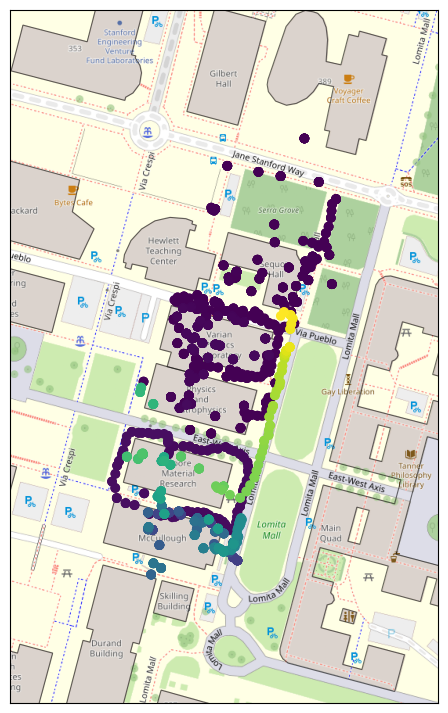

In [46]:
fig, ax, osm_metadata = osm_context.generate_base_axis()
phone_lats, phone_lons = joined_df['latitude'], joined_df['longitude']
colors = np.exp(-1 * (joined_df["sample_timestamp_utc"].max() - joined_df["sample_timestamp_utc"]).dt.total_seconds() / 600)
world_lons, world_lats = osm_context.to_world(phone_lons, phone_lats)

ax.scatter(world_lons, world_lats, c = colors)

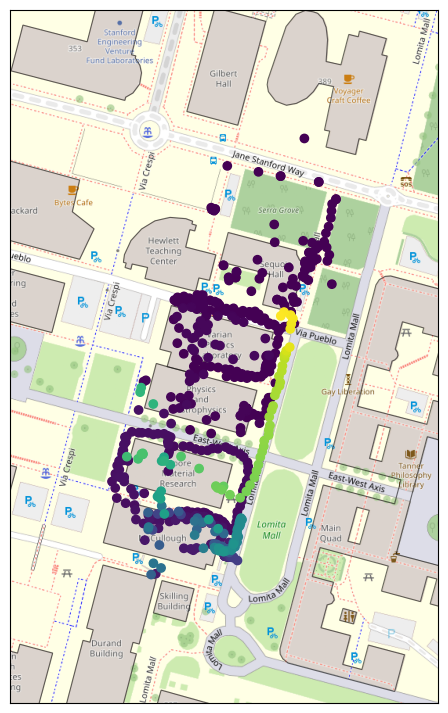

In [47]:
fig, ax, osm_metadata = osm_context.generate_base_axis()

phone_lats, phone_lons = phone_location_df['latitude'], phone_location_df['longitude']
colors = np.exp(-1 * (phone_location_df["timestamp"].max() - phone_location_df["timestamp"]).dt.total_seconds() / 600)
world_lons, world_lats = osm_context.to_world(phone_lons, phone_lats)

ax.scatter(world_lons, world_lats, c = colors)

## Clean data to prepare for inference

In [48]:
joined_df.head()

,measurement_set_id,sample_index,collector_id,environment,floor,measurement_set_timestamp_utc,sample_timestamp_utc,wdutil_rssi_dbm,wdutil_rssi_effective_dbm,wdutil_noise_dbm,wdutil_noise_effective_dbm,wdutil_tx_rate,unredactor_bssid,phone_gps_asof_timestamp,phone_gps_asof_sample_index,latitude,longitude,phone_gps_asof_altitude_m
0,07d6fa75def0,0,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:02.508330+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:04+00:00,13.0,37.428992,-122.171906,31.672413
1,07d6fa75def0,1,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:03.719977+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:04+00:00,13.0,37.428992,-122.171906,31.672413
2,07d6fa75def0,2,kevinluo,indoor,1,2026-04-28 00:11:02.402561+00:00,2026-04-28 00:11:04.951550+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:04+00:00,13.0,37.428992,-122.171906,31.672413
3,825d2cb1e35a,0,kevinluo,indoor,1,2026-04-28 00:11:07.403333+00:00,2026-04-28 00:11:07.470753+00:00,-45,-45.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:09+00:00,14.0,37.428992,-122.171906,31.672413
4,825d2cb1e35a,1,kevinluo,indoor,1,2026-04-28 00:11:07.403333+00:00,2026-04-28 00:11:08.676819+00:00,-44,-44.0,-97,-97.0,573.0,a8:3a:79:c7:75:12,2026-04-28 00:11:09+00:00,14.0,37.428992,-122.171906,31.672413


In [49]:
# grab "interesting" columns, drop anything without location
df_clean = joined_df[
    [
        'environment', 'floor',
        "sample_timestamp_utc",
        'wdutil_rssi_effective_dbm',
        'wdutil_noise_effective_dbm',
        'unredactor_bssid',
        'measurement_set_id',
        'sample_index',
        "phone_gps_asof_timestamp",
        "latitude",
        "longitude"
    ]
].copy().rename(columns={
    "wdutil_rssi_effective_dbm": "rssi_sample",
    "wdutil_noise_effective_dbm": "noise_sample",
    "sample_timestamp_utc": "timestamp",
    "phone_gps_asof_timestamp": "location_timestamp",
    "unredactor_bssid": "ap",
    "measurement_set_id": "mid",
    "sample_index": "index",
}).assign(
    **{
        "rssi_signal_measured": lambda df: ~df['rssi_sample'].isna(),
        "noise_signal_measured": lambda df: ~df['noise_sample'].isna(),
    }
)

df_clean = df_clean.dropna(subset=['latitude', 'longitude'])

df_clean['indoor'] = (df_clean['environment'] == 'indoor')
df_clean['floor'] = df_clean['floor'].fillna(0)


# convert to datetime and all to PDT
df_clean['timestamp'] = df_clean['timestamp'].dt.tz_convert(
    "America/Los_Angeles")
df_clean['date'] = df_clean['timestamp'].dt.date
df_clean['time_pdt'] = df_clean['timestamp'].dt.time

In [50]:
df_clean.head()

,environment,floor,timestamp,rssi_sample,noise_sample,ap,mid,index,location_timestamp,latitude,longitude,rssi_signal_measured,noise_signal_measured,indoor,date,time_pdt
0,indoor,1,2026-04-27 17:11:02.508330-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,07d6fa75def0,0,2026-04-28 00:11:04+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:02.508330
1,indoor,1,2026-04-27 17:11:03.719977-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,07d6fa75def0,1,2026-04-28 00:11:04+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:03.719977
2,indoor,1,2026-04-27 17:11:04.951550-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,07d6fa75def0,2,2026-04-28 00:11:04+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:04.951550
3,indoor,1,2026-04-27 17:11:07.470753-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,825d2cb1e35a,0,2026-04-28 00:11:09+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:07.470753
4,indoor,1,2026-04-27 17:11:08.676819-07:00,-44.0,-97.0,a8:3a:79:c7:75:12,825d2cb1e35a,1,2026-04-28 00:11:09+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:08.676819


In [51]:
df_clean.groupby("mid")['ap'].nunique().value_counts()

ap
1    622
Name: count, dtype: int64

In [52]:
df_clean.groupby("mid")["rssi_signal_measured"].sum().value_counts()

# rssi_signal_measured
# 3    614
# 0      5
# 2      2
# 1      1
# Name: count, dtype: int64

rssi_signal_measured
3    614
0      5
2      2
1      1
Name: count, dtype: int64

In [53]:
# this is weirder
df_clean.groupby("mid")["noise_signal_measured"].sum().value_counts()

# noise_signal_measured
# 3    497
# 0     71
# 2     32
# 1     22
# Name: count, dtype: int64

noise_signal_measured
3    497
0     71
2     32
1     22
Name: count, dtype: int64

<Axes: >

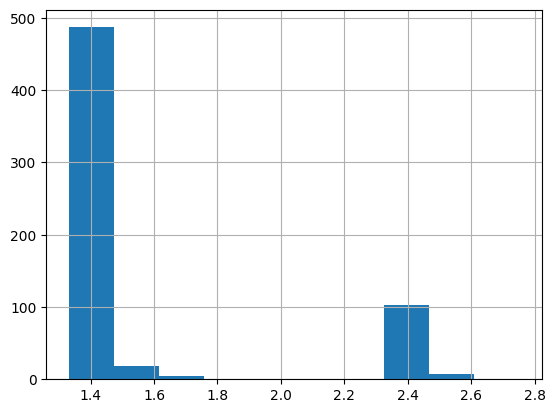

In [54]:
df_clean.groupby("mid")['timestamp'].agg(
    lambda v: v.max() - v.min()
).dt.total_seconds().hist()

array([[<Axes: title={'center': 'rssi_range'}>,
        <Axes: title={'center': 'mean'}>],
       [<Axes: title={'center': 'rssi_range_over_mean'}>, <Axes: >]],
      dtype=object)

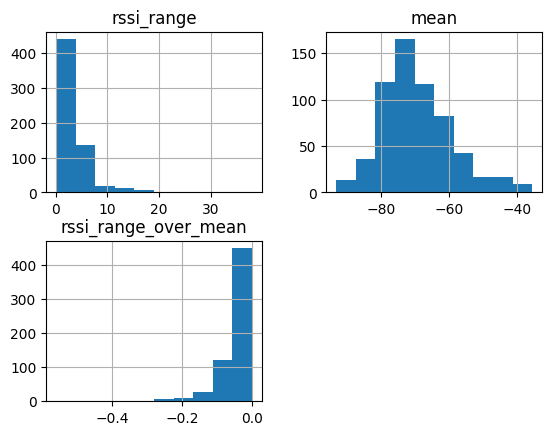

In [55]:
df_clean.groupby("mid")["rssi_sample"].agg(
    rssi_range=lambda v: v.max() - v.min(),
    mean="mean",
    rssi_range_over_mean=lambda v: (v.max() - v.min()) / v.mean(),
).hist()

In [56]:
df_clean[['rssi_set', 'noise_set']] = df_clean.groupby("mid", sort=False)[['rssi_sample', 'noise_sample']].transform("mean")
df_clean[['rssi_n_valid', 'noise_n_valid']] = df_clean.groupby("mid", sort=False)[['rssi_sample', 'noise_sample']].transform("count")

In [57]:
df_clean.head()

,environment,floor,timestamp,rssi_sample,noise_sample,ap,mid,index,location_timestamp,latitude,longitude,rssi_signal_measured,noise_signal_measured,indoor,date,time_pdt,rssi_set,noise_set,rssi_n_valid,noise_n_valid
0,indoor,1,2026-04-27 17:11:02.508330-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,07d6fa75def0,0,2026-04-28 00:11:04+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:02.508330,-45.000000,-97.0,3,3
1,indoor,1,2026-04-27 17:11:03.719977-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,07d6fa75def0,1,2026-04-28 00:11:04+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:03.719977,-45.000000,-97.0,3,3
2,indoor,1,2026-04-27 17:11:04.951550-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,07d6fa75def0,2,2026-04-28 00:11:04+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:04.951550,-45.000000,-97.0,3,3
3,indoor,1,2026-04-27 17:11:07.470753-07:00,-45.0,-97.0,a8:3a:79:c7:75:12,825d2cb1e35a,0,2026-04-28 00:11:09+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:07.470753,-44.333333,-97.0,3,3
4,indoor,1,2026-04-27 17:11:08.676819-07:00,-44.0,-97.0,a8:3a:79:c7:75:12,825d2cb1e35a,1,2026-04-28 00:11:09+00:00,37.428992,-122.171906,True,True,True,2026-04-27,17:11:08.676819,-44.333333,-97.0,3,3


In [58]:
reorder_cols = ['date', 'time_pdt', 'latitude', 'longitude', 'indoor', 'ap',
                'floor', 'rssi_set', 'rssi_sample', 'rssi_signal_measured', 'rssi_n_valid', 'noise_set', 'noise_sample', 'noise_n_valid',
                'noise_signal_measured', 'timestamp', 'location_timestamp', 'mid', 'index']

In [59]:
set(df_clean.columns) - set(reorder_cols), set(reorder_cols) - set(df_clean.columns)

({'environment'}, set())

In [60]:
# mean already ignores nans

# reorder columns
df_clean = df_clean[reorder_cols]

# assert df_clean.isna().sum(axis=0).max() == (
#     ~df_clean['rssi_signal_measured']).sum(), "Unhandled NAs present in data"

write_wifi_dataframe(df_clean, '../data/df_clean.csv')
display(df_clean.head(12))

,date,time_pdt,latitude,longitude,indoor,ap,floor,rssi_set,rssi_sample,rssi_signal_measured,rssi_n_valid,noise_set,noise_sample,noise_n_valid,noise_signal_measured,timestamp,location_timestamp,mid,index
0,2026-04-27,17:11:02.508330,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:02.508330-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,0
1,2026-04-27,17:11:03.719977,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:03.719977-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,1
2,2026-04-27,17:11:04.951550,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:04.951550-07:00,2026-04-28 00:11:04+00:00,07d6fa75def0,2
3,2026-04-27,17:11:07.470753,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:07.470753-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,0
4,2026-04-27,17:11:08.676819,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:08.676819-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,1
5,2026-04-27,17:11:09.892676,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-44.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:09.892676-07:00,2026-04-28 00:11:09+00:00,825d2cb1e35a,2
6,2026-04-27,17:11:12.483688,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:12.483688-07:00,2026-04-28 00:11:15+00:00,9652bfea7428,0
7,2026-04-27,17:11:13.701782,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-45.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:13.701782-07:00,2026-04-28 00:11:15+00:00,9652bfea7428,1
8,2026-04-27,17:11:14.901204,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-44.333333,-43.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:14.901204-07:00,2026-04-28 00:11:15+00:00,9652bfea7428,2
9,2026-04-27,17:11:17.500943,37.428992,-122.171906,True,a8:3a:79:c7:75:12,1,-45.000000,-42.0,True,3,-97.0,-97.0,3,True,2026-04-27 17:11:17.500943-07:00,2026-04-28 00:11:20+00:00,e4600c838f5d,0
